In [152]:
import pandas as pd
import numpy as np

In [153]:
# df = pd.read_csv('/Users/jeffwinchell/Documents/cmu/coursework/spring_2026/funbio/cell-cycle-ti/data/GSE142277/GSE142277_RAW/GSM4224315_out_gene_exon_tagged.dge_exonssf002_WT.txt',sep='\t')
# df = pd.read_csv('../data/toy_datasets/swiss_0.5noise.csv')

In [154]:
# drop zero-expressed genes
# df[df.values[:,1:].astype(int).sum(axis=1)>0].reset_index(drop=True).shape

#### more sample datasets

In [155]:
def generate_toroidal_helix(major_r=100, minor_r=10, turns=20, num_points=1000):
    """Generates a 3D toroidal helix dataset."""
    t = np.linspace(0, 2 * np.pi, num_points)
    
    # Parametric equations for a Toroidal Helix
    x = (major_r + minor_r * np.cos(turns * t)) * np.cos(t)
    y = (major_r + minor_r * np.cos(turns * t)) * np.sin(t)
    z = minor_r * np.sin(turns * t)
    
    return pd.DataFrame({'x': x,'y': y, 'z': z})

def make_tree(n=3000, split_ts=(0.35, 0.65), branch_probs=(0.6, 0.3, 0.1),
              noise=0.03, seed=0):
    rng = np.random.default_rng(seed)
    t = rng.random(n)
    b = np.zeros(n, dtype=int)  # 0 trunk, 1/2/3 branches

    split1, split2 = split_ts

    after1 = t >= split1
    b[after1] = rng.choice([1,2,3], size=after1.sum(), p=branch_probs)

    X = np.zeros((n, 2))
    for i in range(n):
        if t[i] < split1:
            s = t[i]/split1
            X[i] = [s, 0.0]
        else:
            s = (t[i]-split1)/(1-split1)
            base = np.array([1.0, 0.0])
            if b[i] == 1:      # up branch
                X[i] = base + [0.9*s, 0.8*s]
            elif b[i] == 2:    # down branch
                X[i] = base + [0.9*s, -0.8*s]
            else:              # “late” branch that peels off later
                if t[i] < split2:
                    u = (t[i]-split1)/(split2-split1)
                    X[i] = base + [0.9*u, 0.15*np.sin(2*np.pi*u)]
                else:
                    u = (t[i]-split2)/(1-split2)
                    mid = base + [0.9, 0.0]
                    X[i] = mid + [0.4*u, 0.9*u]

    X += rng.normal(scale=noise, size=X.shape)
    return X, t, b

X,_,_ = make_tree(seed=None)

#### KNN graph

In [156]:
from sklearn.neighbors import NearestNeighbors

# we can do this from scratch
k = 20
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, indices = nbrs.kneighbors(X)

## Diffusion Maps

In [157]:
import numpy as np
N = X.shape[0]
K = np.zeros((N,N)) # will update this to be a CSR

#
alpha = 0.5
for i in range(len(indices)):
    for j in range(k):
        K[i,indices[i,j]] = np.exp(-distances[i,j]**2 /(distances[i,k-1]*distances[indices[i,j],k-1])) # adaptive kernel

K = (K+K.T)/2 # symmetrize

# density normalization
K_tilde = K.copy()
q = np.sum(K_tilde,axis=1)
scale = q ** (-alpha)
K_tilde = (scale[:, None] * K) * scale[None, :] 


# row normalize
row_sums = np.array(K_tilde.sum(axis=1)).flatten()
P = K_tilde*(1/row_sums[:,None]) # MARKOV MATRIX

D = K_tilde.sum(axis=1).ravel() # diagonal matrix of row sums (as vector)

D_inv_sqrt = 1/np.sqrt(D)
D_sqrt = np.sqrt(D)

S = (D_sqrt[:, None] * P) * D_inv_sqrt[None, :] # symmetric matrix (D^0.5 @ P @ D^(-0.5))

print(np.max(np.abs(S-S.T))) # should be very small

1.1102230246251565e-16


#### QC

In [158]:
# 1) row sums ~ 1
rs = np.asarray(P.sum(axis=1)).ravel()
print(rs.min(), rs.max())

# 2) nonnegativity
print(P.min())

# 3) sparsity
print(np.nonzero(P)[0].shape[0], "nonzeros out of", P.shape[0]**2)

0.9999999999999997 1.0000000000000004
0.0
71134 nonzeros out of 9000000


In [159]:
from scipy.sparse.linalg import eigs

import numpy as np
from scipy.sparse.linalg import eigsh  # for nonsymmetric P
def diffusion_map_from_Ktilde(K_tilde, n_components=10, t=1, eps=1e-12):
    """
    K_tilde: symmetric sparse matrix after density normalization (before row-normalization)
    Returns: embedding (N, n_components), lambdas, psis
    """
    d = np.asarray(K_tilde.sum(axis=1)).ravel()
    d = np.maximum(d, eps)

    # symmetric conjugate S = D^{-1/2} K_tilde D^{-1/2}
    inv_sqrt_d = 1.0 / np.sqrt(d)
    S = K_tilde* (inv_sqrt_d[:, None])*(inv_sqrt_d[None, :])

    # top eigenpairs (largest eigenvalues)
    vals, vecs = eigsh(S, k=n_components+1, which="LA")
    order = np.argsort(-vals)
    vals, vecs = vals[order], vecs[:, order]

    # drop the trivial first component (lambda ~ 1)
    lambdas = vals[1:n_components+1]
    u = vecs[:, 1:n_components+1]

    # right eigenvectors of P: psi = D^{-1/2} u
    psis = u * inv_sqrt_d[:, None]

    # diffusion coordinates
    emb = psis * (lambdas ** t)

    return emb, lambdas, psis

emb, lambdas, psis = diffusion_map_from_Ktilde(K_tilde,) # diffusion compoents, eigenvals, eigenvectors



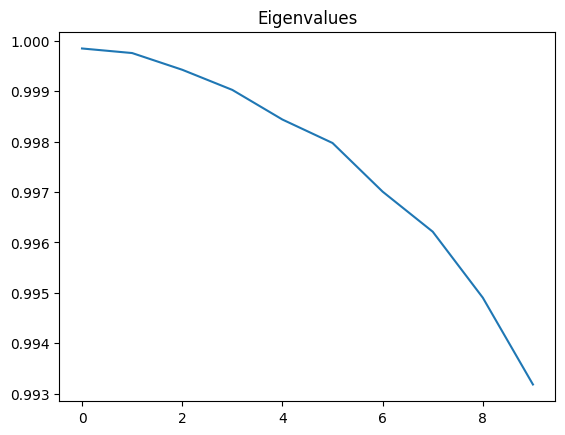

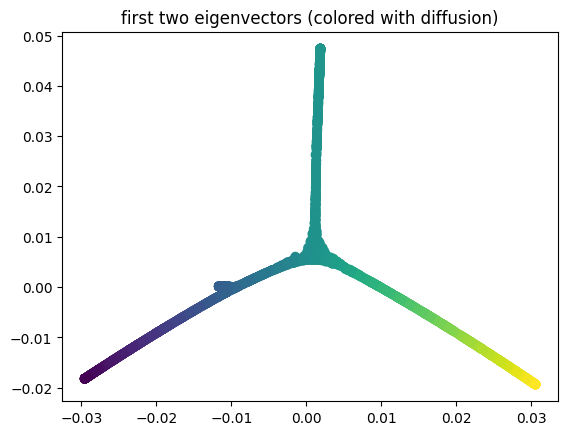

<Figure size 640x480 with 0 Axes>

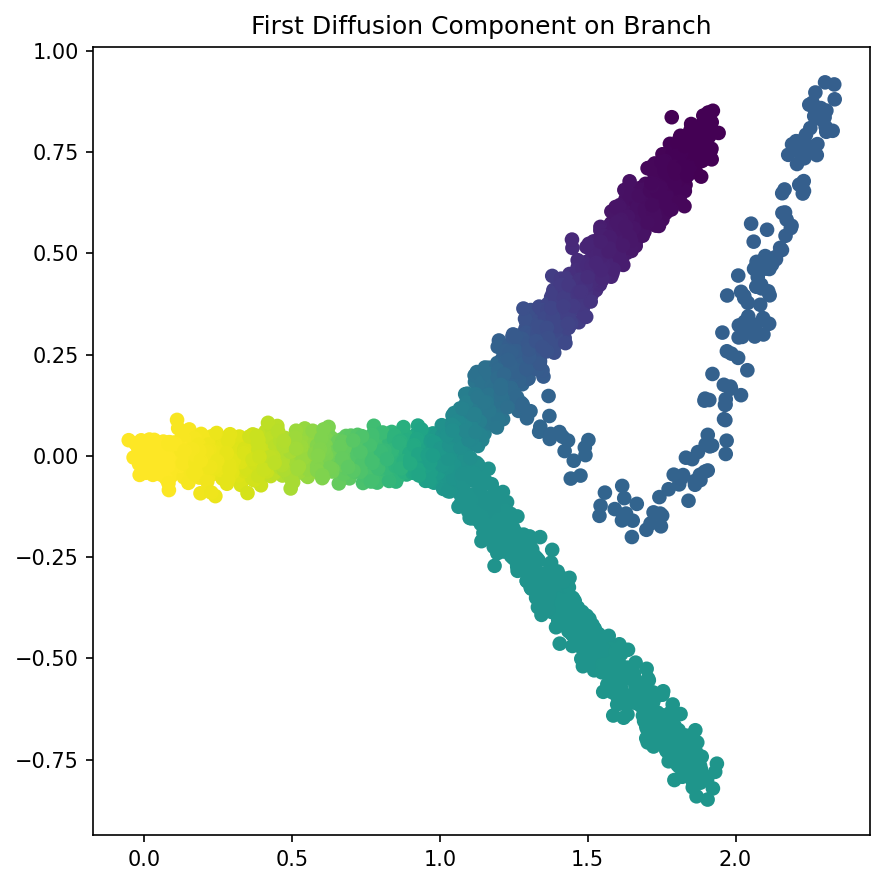

In [160]:
import matplotlib.pyplot as plt
plt.plot(lambdas)
plt.title('Eigenvalues')
plt.figure()
df = pd.DataFrame(data=np.concatenate([X,emb],axis=1),columns=['x','y']+[f"diff_{i+1}" for i in range(len(emb[0]))])

plt.scatter(psis[:,0],psis[:,1],c=df['diff_1'])
plt.title('first two eigenvectors (colored with diffusion)')
plt.figure()

# # 3D Plot
# import seaborn as sns
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# df[['diff_1','diff_2']] = emb[:,[0,1]]
# fig = plt.figure(figsize=(6,6),dpi=150)
# ax = Axes3D(fig, auto_add_to_figure=False)
# fig.add_axes(ax)

# sc = ax.scatter(df['x'],df['y'],df['z'],c=df['diff_1'])
# ax.set_title("First Diffusion Component on Swiss Roll")
# fig.tight_layout()

# 2D plot
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax= plt.subplots(figsize=(6,6),dpi=150)
# ax = Axes3D(fig, auto_add_to_figure=False)
# fig.add_axes(ax)

sc = ax.scatter(df['x'],df['y'],c=df['diff_1'])
ax.set_title("First Diffusion Component on Branch")
fig.tight_layout()
